<h1> House Sales Project </h1>
<h2> Approach Statement </h2>
<p>
    I will be working with King County House Sales dataset to predict house prices in King County, Washington USA. The dataset contains useful information about each property relating to its key features, including the size of the property, number of bedrooms/ bathrooms. The dataset is quite large containing 21,597 rows and 21 columns. I will explore the data to discover which features strongly correlate with house price and identify key features to support modelling to predict house prices. First I will review the dataset and identify any issues within the data and make decisions on how to proceed and correct any errors/ outliers. Then I will begin to explore features, and understand how the features correlate with house price and identify key features for modelling.  
</p>

# Task 1

In [1]:
# First I will import modules required to explore the data.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Next I will load the data into a pandas dataframe.
house_data = pd.read_csv('kc_house_data.csv')

In [3]:
# Now I will explore the data to understand what it looks like and what I am working with.
house_data.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,10/13/2014,221900.0,3,1.00,1180,5650,1.0,NaN,0.0,...,7,1180,0.0,1955,0.0,98178,47.5112,-122.257,1340,5650
1,6414100192,12/9/2014,538000.0,3,2.25,2570,7242,2.0,0.0,0.0,...,7,2170,400.0,1951,1991.0,98125,47.7210,-122.319,1690,7639
2,5631500400,2/25/2015,180000.0,2,1.00,770,10000,1.0,0.0,0.0,...,6,770,0.0,1933,NaN,98028,47.7379,-122.233,2720,8062
3,2487200875,12/9/2014,604000.0,4,3.00,1960,5000,1.0,0.0,0.0,...,7,1050,910.0,1965,0.0,98136,47.5208,-122.393,1360,5000
4,1954400510,2/18/2015,510000.0,3,2.00,1680,8080,1.0,0.0,0.0,...,8,1680,0.0,1987,0.0,98074,47.6168,-122.045,1800,7503


In [4]:
house_data.tail()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21592,263000018,5/21/2014,360000.0,3,2.50,1530,1131,3.0,0.0,0.0,...,8,1530,0.0,2009,0.0,98103,47.6993,-122.346,1530,1509
21593,6600060120,2/23/2015,400000.0,4,2.50,2310,5813,2.0,0.0,0.0,...,8,2310,0.0,2014,0.0,98146,47.5107,-122.362,1830,7200
21594,1523300141,6/23/2014,402101.0,2,0.75,1020,1350,2.0,0.0,0.0,...,7,1020,0.0,2009,0.0,98144,47.5944,-122.299,1020,2007
21595,291310100,1/16/2015,400000.0,3,2.50,1600,2388,2.0,NaN,0.0,...,8,1600,0.0,2004,0.0,98027,47.5345,-122.069,1410,1287
21596,1523300157,10/15/2014,325000.0,2,0.75,1020,1076,2.0,0.0,0.0,...,7,1020,0.0,2008,0.0,98144,47.5941,-122.299,1020,1357


In [5]:
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21597 non-null  int64  
 1   date           21597 non-null  str    
 2   price          21597 non-null  float64
 3   bedrooms       21597 non-null  int64  
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  int64  
 6   sqft_lot       21597 non-null  int64  
 7   floors         21597 non-null  float64
 8   waterfront     19221 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  int64  
 13  sqft_basement  21597 non-null  str    
 14  yr_built       21597 non-null  int64  
 15  yr_renovated   17755 non-null  float64
 16  zipcode        21597 non-null  int64  
 17  lat            21597 non-null  float64
 18  long           21

In [6]:
house_data.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.159700e+04,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,19221.000000,21534.000000,21597.000000,21597.000000,21597.000000,21597.000000,17755.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,4.580474e+09,5.402966e+05,3.373200,2.115826,2080.321850,1.509941e+04,1.494096,0.007596,0.233863,3.409825,7.657915,1788.596842,1970.999676,83.636778,98077.951845,47.560093,-122.213982,1986.620318,12758.283512
std,2.876736e+09,3.673681e+05,0.926299,0.768984,918.106125,4.141264e+04,0.539683,0.086825,0.765686,0.650546,1.173200,827.759761,29.375234,399.946414,53.513072,0.138552,0.140724,685.230472,27274.441950
min,1.000102e+06,7.800000e+04,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,370.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,1951.000000,0.000000,98033.000000,47.471100,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,1975.000000,0.000000,98065.000000,47.571800,-122.231000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


<h2> Initial Findings </h2>
<ul>
    <li>There are 21597 rows.</li>
    <li>Date is stored as str, this may need converting.</li>
    <li>sqft_basement is stored as str, head values appear to be float? Will explore.</li>
    <li>The following columns contain null values which I will need to review:
        <ul>
            <li>waterfront</li>
            <li>view</li>
            <li>yr_renovated</li>
        </ul>
    </li>
    <li> Max bedrooms of 33 seems unusually high</li>
    <li>Zipcode is numerical, should this be str? Better as categorical data</li>
</ul>

<h2> Data Cleaning </h2>

<h3> Convert date column from str to datetime</h3>

In [7]:
# I will fix the date column to be in a proper datetime format "dd/mm/yyyy".
house_data['date'] = pd.to_datetime(house_data['date'])
house_data['date']

0       2014-10-13
1       2014-12-09
2       2015-02-25
3       2014-12-09
4       2015-02-18
           ...    
21592   2014-05-21
21593   2015-02-23
21594   2014-06-23
21595   2015-01-16
21596   2014-10-15
Name: date, Length: 21597, dtype: datetime64[us]

<h3>Review the sqft_basement column and decide format</h3>

In [8]:
# I will check sqft_basement as showing data stored as string instead of int.
house_data['sqft_basement'].unique()

<StringArray>
[   '0.0',  '400.0',  '910.0', '1530.0',      '?',  '730.0', '1700.0',
  '300.0',  '970.0',  '760.0',
 ...
  '207.0',  '915.0',  '556.0',  '417.0',  '143.0',  '508.0', '2810.0',
   '20.0',  '274.0',  '248.0']
Length: 304, dtype: str

In [9]:
# flag non numeric numbers from the unique list
non_numeric = [x for x in house_data['sqft_basement'].unique() 
               if pd.isna(pd.to_numeric(x, errors='coerce'))]
non_numeric

['?']

In [10]:
# Having identified the non-numeric values, I will replace them with NaN and then convert the column to numeric.
house_data['sqft_basement'] = pd.to_numeric(house_data['sqft_basement'], errors='coerce')
house_data['sqft_basement'].info()

<class 'pandas.Series'>
RangeIndex: 21597 entries, 0 to 21596
Series name: sqft_basement
Non-Null Count  Dtype  
--------------  -----  
21143 non-null  float64
dtypes: float64(1)
memory usage: 168.9 KB


<h3>Clean columns with NaN values</h3>

The following columns contain Nan values
<ul>
    <li>waterfront</li>
    <li>view</li>
    <li>yr_renovated</li>
    <li>sqft_basement</li>
</ul>

<h4>--> waterfront</h4>

In [11]:
# First lets check waterfront and assess missing values
house_data['waterfront'].unique()

array([nan,  0.,  1.])

In [12]:
# How many missing values are there in the waterfront column?
house_data['waterfront'].isna().sum() 

np.int64(2376)

In [13]:
# The waterfront column has 0, 1 and NaN values. I will check the percentage of missing values in this column.
house_data['waterfront'].isna().sum() / len(house_data) * 100

np.float64(11.00152798999861)

In [14]:
# I will check how many houses have a waterfront view and how many do not.
house_data['waterfront'].value_counts()

waterfront
0.0    19075
1.0      146
Name: count, dtype: int64

<b>Decision</b>
<p>
    Given that 
    <ul>
        <li>There are 2376 missing values (11%)</li>
        <li>Only 146 known values have a waterfront (less than 1%)</li>
    </ul>
     I will treat all NaN as 0.
</p>

In [15]:
# Convert waterfront missing values to 0, as it is likely that the missing values indicate no waterfront view.
house_data['waterfront'] = house_data['waterfront'].fillna(0)
house_data['waterfront'].value_counts()

waterfront
0.0    21451
1.0      146
Name: count, dtype: int64

<h4>--> view</h4>

In [16]:
# First lets check view and assess missing values
house_data['view'].unique()

array([ 0., nan,  3.,  4.,  2.,  1.])

In [17]:
# How many missing values are there in the view column?
house_data['view'].isna().sum() 

np.int64(63)

In [18]:
# There are 63 missing values in the view column. I will check the percentage of missing values in this column.
house_data['view'].isna().sum() / len(house_data) * 100

np.float64(0.29170718155299347)

In [19]:
# I will check for how values are currently distributed in the view column.
house_data['view'].value_counts()

view
0.0    19422
2.0      957
3.0      508
1.0      330
4.0      317
Name: count, dtype: int64

In [20]:
# Mean mode and median of the view column to determine which is the best approach to filling the missing values.
house_data['view'].mean(), house_data['view'].mode()[0], house_data['view'].median()

(np.float64(0.23386272870808952), np.float64(0.0), np.float64(0.0))

<b>Decision</b>
<p>
    Given that 
    <ul>
        <li>There are 63 missing values (less than 1%)</li>
        <li>View are in ordinal values, 0 the most common</li>
        <li>Median and Mode = 0</li>
        <li>Mean is close to 0</li>
    </ul>
     I will treat all NaN as 0.
</p>

In [21]:
# convert the missing values in the view column to 0, as it is likely that the missing values indicate no view.
house_data['view'] = house_data['view'].fillna(0)
house_data['view'].value_counts().sort_index()

view
0.0    19485
1.0      330
2.0      957
3.0      508
4.0      317
Name: count, dtype: int64

<h4>--> yr_renovated</h4>

In [22]:
# First lets check yr_renovated and assess missing values
house_data['yr_renovated'].unique()

array([   0., 1991.,   nan, 2002., 2010., 1992., 2013., 1994., 1978.,
       2005., 2003., 1984., 1954., 2014., 2011., 1983., 1945., 1990.,
       1988., 1977., 1981., 1995., 2000., 1999., 1998., 1970., 1989.,
       2004., 1986., 2007., 1987., 2006., 1985., 2001., 1980., 1971.,
       1979., 1997., 1950., 1969., 1948., 2009., 2015., 1974., 2008.,
       1968., 2012., 1963., 1951., 1962., 1953., 1993., 1996., 1955.,
       1982., 1956., 1940., 1976., 1946., 1975., 1964., 1973., 1957.,
       1959., 1960., 1967., 1965., 1934., 1972., 1944., 1958.])

In [23]:
# How many missing values are there in the yr_renovated column?
house_data['yr_renovated'].isna().sum() 

np.int64(3842)

In [24]:
# There are 3842 missing values in the yr_renovated column. I will check the percentage of missing values in this column.
house_data['yr_renovated'].isna().sum() / len(house_data) * 100

np.float64(17.78950780200954)

In [25]:
# Check the value counts of the yr_renovated column how these are distributed.
house_data['yr_renovated'].value_counts()

yr_renovated
0.0       17011
2014.0       73
2013.0       31
2003.0       31
2007.0       30
          ...  
1976.0        1
1946.0        1
1959.0        1
1934.0        1
1944.0        1
Name: count, Length: 70, dtype: int64

In [26]:
# Mode and median of the yr_renovated column to determine which is the best approach to filling the missing values.
house_data['yr_renovated'].mode()[0], house_data['yr_renovated'].median()

(np.float64(0.0), np.float64(0.0))

<b>Decision</b>
<p>
    Given that
    <ul>
        <li>There are 3842 missing values (18%)</li>
        <li>17,011 rows have a value of 0, meaning never renovated</li>
        <li>NaN likely also means never renovated</li>
        <li>Knowing whether the house has been renovated will be more important than when</li>
    </ul>
    I will create a new binary column "renovated" (1 = renovated, 0 = not renovated),
    treating both 0 and NaN as not renovated. The yr_renovated column will be dropped.
</p>

In [27]:
# New binary column to indicate whether a house has been renovated or not.
house_data['renovated'] = house_data['yr_renovated'].apply(lambda x: 1 if x > 0 else 0)
house_data['renovated'].value_counts()

renovated
0    20853
1      744
Name: count, dtype: int64

In [28]:
# Now i will drop the yr_renovated column as it is no longer needed.
house_data = house_data.drop('yr_renovated', axis=1, errors='ignore')
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   date           21597 non-null  datetime64[us]
 2   price          21597 non-null  float64       
 3   bedrooms       21597 non-null  int64         
 4   bathrooms      21597 non-null  float64       
 5   sqft_living    21597 non-null  int64         
 6   sqft_lot       21597 non-null  int64         
 7   floors         21597 non-null  float64       
 8   waterfront     21597 non-null  float64       
 9   view           21597 non-null  float64       
 10  condition      21597 non-null  int64         
 11  grade          21597 non-null  int64         
 12  sqft_above     21597 non-null  int64         
 13  sqft_basement  21143 non-null  float64       
 14  yr_built       21597 non-null  int64         
 15  zipcode        21597 non-null 

<h4>--> sqft_basement</h4>

In [29]:
# First lets check sqft_basement and assess missing values
house_data['sqft_basement'].unique()

array([   0.,  400.,  910., 1530.,   nan,  730., 1700.,  300.,  970.,
        760.,  720.,  700.,  820.,  780.,  790.,  330., 1620.,  360.,
        588., 1510.,  410.,  990.,  600.,  560.,  550., 1000., 1600.,
        500., 1040.,  880., 1010.,  240.,  265.,  290.,  800.,  540.,
        710.,  840.,  380.,  770.,  480.,  570., 1490.,  620., 1250.,
       1270.,  120.,  650.,  180., 1130.,  450., 1640., 1460., 1020.,
       1030.,  750.,  640., 1070.,  490., 1310.,  630., 2000.,  390.,
        430.,  850.,  210., 1430., 1950.,  440.,  220., 1160.,  860.,
        580., 2060., 1820., 1180.,  200., 1150., 1200.,  680.,  530.,
       1450., 1170., 1080.,  960.,  280.,  870., 1100.,  460., 1400.,
        660., 1220.,  900.,  420., 1580., 1380.,  475.,  690.,  270.,
        350.,  935., 1370.,  980., 1470.,  160.,  950.,   50.,  740.,
       1780., 1900.,  340.,  470.,  370.,  140., 1760.,  130.,  520.,
        890., 1110.,  150., 1720.,  810.,  190., 1290.,  670., 1800.,
       1120., 1810.,

In [30]:
# How many missing values are there in the sqft_basement column?
house_data['sqft_basement'].isna().sum() 

np.int64(454)

In [31]:
# Percentage of missing values in the sqft_basement column.
house_data['sqft_basement'].isna().sum() / len(house_data) * 100

np.float64(2.1021438162707784)

In [32]:
# Check the value counts of the sqft_basement column how these are distributed.
house_data['sqft_basement'].value_counts()

sqft_basement
0.0       12826
600.0       217
500.0       209
700.0       208
800.0       201
          ...  
508.0         1
2810.0        1
20.0          1
274.0         1
248.0         1
Name: count, Length: 303, dtype: int64

In [33]:
# Mode and median of the sqft_basement column to determine which is the best approach to filling the missing values.
house_data['sqft_basement'].mode()[0], house_data['sqft_basement'].median()

(np.float64(0.0), np.float64(0.0))

There is a different approach here, there is additional information relating to sqft that might provide the missing values....

In [34]:
# Check if sqft_living - sqft_above = sqft_basement for non-null rows
house_data['sqft_derived'] = house_data['sqft_living'] - house_data['sqft_above']

# Compare derived vs actual on non-null rows
comparison = house_data[house_data['sqft_basement'].notna()][['sqft_basement', 'sqft_derived']]
comparison.head(10)

,sqft_basement,sqft_derived
0,0.0,0
1,400.0,400
2,0.0,0
3,910.0,910
4,0.0,0
5,1530.0,1530
7,0.0,0
8,730.0,730
9,0.0,0
10,1700.0,1700


In [35]:
# Check how many rows match exactly
exact_match = (comparison['sqft_basement'] == comparison['sqft_derived']).sum()
total = len(comparison)
print(f"Exact matches: {exact_match} / {total} ({exact_match/total*100:.1f}%)")

Exact matches: 21143 / 21143 (100.0%)


<b>Decision</b>
<p>
    Given that
    <ul>
        <li>There are NaN values in the sqft_basement column</li>
        <li>The dataset contains sqft_living (total interior space) and sqft_above (above ground space)</li>
        <li>A 100% exact match was confirmed between sqft_basement and sqft_living - sqft_above for all non-null rows</li>
    </ul>
    The missing values can be derived exactly using:
     sqft_basement = sqft_living - sqft_above.
    This is a mathematically exact relationship, not an assumption.
</p>

In [36]:
# 100% match confirmed: sqft_basement = sqft_living - sqft_above
# Fill NaN values using this derived relationship
house_data['sqft_basement'] = house_data['sqft_basement'].fillna(house_data['sqft_derived'])

# Drop the temporary derived column
house_data = house_data.drop('sqft_derived', axis=1)

house_data['sqft_basement'].isna().sum() 

np.int64(0)

<h3>Review the max 33 Bedrooms</h3>

In [37]:
# I will check all the unique values in the bedrooms column to see if the 33 value is an outlier or a data entry error.
house_data['bedrooms'].unique()

array([ 3,  2,  4,  5,  1,  6,  7,  8,  9, 11, 10, 33])

In [38]:
# I will check the value counts of the bedrooms column to see how many houses have 33 bedrooms.
house_data['bedrooms'].value_counts()

bedrooms
3     9824
4     6882
2     2760
5     1601
6      272
1      196
7       38
8       13
9        6
10       3
11       1
33       1
Name: count, dtype: int64

In [39]:
# Median, mean and mode of the bedrooms column to determine approach to handling the 33 bedroom value.
house_data['bedrooms'].median(), house_data['bedrooms'].mean(), house_data['bedrooms'].mode()[0]

(np.float64(3.0), np.float64(3.3731999814789093), np.int64(3))

<b>Decision</b>
<p>
    Given that
    <ul>
        <li>No other entry has bedroom greater than 11</li>
        <li>3 bedrooms is the most common number of bedrooms</li>
        <li>Median, mean and mode are all 3</li>
        <li>33 is likely a data entry error for "3"</li>
    </ul>
    I will replace the value with a 3
</p>

In [40]:
# I will replace the 33 bedroom value with a 3
house_data['bedrooms'] = house_data['bedrooms'].replace(33, 3)
house_data['bedrooms'].value_counts()

bedrooms
3     9825
4     6882
2     2760
5     1601
6      272
1      196
7       38
8       13
9        6
10       3
11       1
Name: count, dtype: int64

<h3>Review zipcode</h3>

In [41]:
# I will check the unique values for zipcode
house_data['zipcode'].unique()

array([98178, 98125, 98028, 98136, 98074, 98053, 98003, 98198, 98146,
       98038, 98007, 98115, 98107, 98126, 98019, 98103, 98002, 98133,
       98040, 98092, 98030, 98119, 98112, 98052, 98027, 98117, 98058,
       98001, 98056, 98166, 98023, 98070, 98148, 98105, 98042, 98008,
       98059, 98122, 98144, 98004, 98005, 98034, 98075, 98116, 98010,
       98118, 98199, 98032, 98045, 98102, 98077, 98108, 98168, 98177,
       98065, 98029, 98006, 98109, 98022, 98033, 98155, 98024, 98011,
       98031, 98106, 98072, 98188, 98014, 98055, 98039])

In [42]:
house_data['zipcode'].info()

<class 'pandas.Series'>
RangeIndex: 21597 entries, 0 to 21596
Series name: zipcode
Non-Null Count  Dtype
--------------  -----
21597 non-null  int64
dtypes: int64(1)
memory usage: 168.9 KB


In [43]:
# zipcode being stored as an int does not make sense as it references to a location which is categorical data. I will convert the zipcode column to a string.
house_data['zipcode'] = house_data['zipcode'].astype(str)
house_data['zipcode'].info()

<class 'pandas.Series'>
RangeIndex: 21597 entries, 0 to 21596
Series name: zipcode
Non-Null Count  Dtype
--------------  -----
21597 non-null  str  
dtypes: str(1)
memory usage: 168.9 KB


<h3>Validate Cleansed Data</h3>

In [44]:
# I will review the summary information of the dataset again to check the changes i have made.
house_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21597 non-null  int64         
 1   date           21597 non-null  datetime64[us]
 2   price          21597 non-null  float64       
 3   bedrooms       21597 non-null  int64         
 4   bathrooms      21597 non-null  float64       
 5   sqft_living    21597 non-null  int64         
 6   sqft_lot       21597 non-null  int64         
 7   floors         21597 non-null  float64       
 8   waterfront     21597 non-null  float64       
 9   view           21597 non-null  float64       
 10  condition      21597 non-null  int64         
 11  grade          21597 non-null  int64         
 12  sqft_above     21597 non-null  int64         
 13  sqft_basement  21597 non-null  float64       
 14  yr_built       21597 non-null  int64         
 15  zipcode        21597 non-null 

In [45]:
house_data.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,lat,long,sqft_living15,sqft_lot15,renovated
count,2.159700e+04,21597,2.159700e+04,21597.000000,21597.000000,21597.000000,2.159700e+04,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000,21597.000000
mean,4.580474e+09,2014-10-29 04:20:38.171968,5.402966e+05,3.371811,2.115826,2080.321850,1.509941e+04,1.494096,0.006760,0.233181,3.409825,7.657915,1788.596842,291.725008,1970.999676,47.560093,-122.213982,1986.620318,12758.283512,0.034449
min,1.000102e+06,2014-05-02 00:00:00,7.800000e+04,1.000000,0.500000,370.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,3.000000,370.000000,0.000000,1900.000000,47.155900,-122.519000,399.000000,651.000000,0.000000
25%,2.123049e+09,2014-07-22 00:00:00,3.220000e+05,3.000000,1.750000,1430.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,47.471100,-122.328000,1490.000000,5100.000000,0.000000
50%,3.904930e+09,2014-10-16 00:00:00,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,47.571800,-122.231000,1840.000000,7620.000000,0.000000
75%,7.308900e+09,2015-02-17 00:00:00,6.450000e+05,4.000000,2.500000,2550.000000,1.068500e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,47.678000,-122.125000,2360.000000,10083.000000,0.000000
max,9.900000e+09,2015-05-27 00:00:00,7.700000e+06,11.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,47.777600,-121.315000,6210.000000,871200.000000,1.000000
std,2.876736e+09,NaN,3.673681e+05,0.904096,0.768984,918.106125,4.141264e+04,0.539683,0.081944,0.764673,0.650546,1.173200,827.759761,442.667800,29.375234,0.138552,0.140724,685.230472,27274.441950,0.182384


Overall I am happy with cleansing and will proceed to explore the data

<h3> Data Cleaning Summary</h3>

I have made the following decisions:
- Converted 'date' column from 'str' datatype to 'datetime'
- Converted 'sqft_basement' column from 'str' to 'float'
- Resolved 'null' / 'Nan' values in:
    - waterfront
    - view
    - yr_renovated
    - sqft_basement
- Corrected the '33' value in 'bedrooms' column
- Converted zipcode from 'float' to 'str' as categorical data. 

<h2> Exploratory Data Analysis (EDA) and Visualisations</h2>

In [46]:
# I will now explore the data, i will take another look at the dataset
house_data.head(10)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,renovated
0,7129300520,2014-10-13,221900.0,3,1.00,1180,5650,1.0,0.0,0.0,...,7,1180,0.0,1955,98178,47.5112,-122.257,1340,5650,0
1,6414100192,2014-12-09,538000.0,3,2.25,2570,7242,2.0,0.0,0.0,...,7,2170,400.0,1951,98125,47.7210,-122.319,1690,7639,1
2,5631500400,2015-02-25,180000.0,2,1.00,770,10000,1.0,0.0,0.0,...,6,770,0.0,1933,98028,47.7379,-122.233,2720,8062,0
3,2487200875,2014-12-09,604000.0,4,3.00,1960,5000,1.0,0.0,0.0,...,7,1050,910.0,1965,98136,47.5208,-122.393,1360,5000,0
4,1954400510,2015-02-18,510000.0,3,2.00,1680,8080,1.0,0.0,0.0,...,8,1680,0.0,1987,98074,47.6168,-122.045,1800,7503,0
5,7237550310,2014-05-12,1230000.0,4,4.50,5420,101930,1.0,0.0,0.0,...,11,3890,1530.0,2001,98053,47.6561,-122.005,4760,101930,0
6,1321400060,2014-06-27,257500.0,3,2.25,1715,6819,2.0,0.0,0.0,...,7,1715,0.0,1995,98003,47.3097,-122.327,2238,6819,0
7,2008000270,2015-01-15,291850.0,3,1.50,1060,9711,1.0,0.0,0.0,...,7,1060,0.0,1963,98198,47.4095,-122.315,1650,9711,0
8,2414600126,2015-04-15,229500.0,3,1.00,1780,7470,1.0,0.0,0.0,...,7,1050,730.0,1960,98146,47.5123,-122.337,1780,8113,0
9,3793500160,2015-03-12,323000.0,3,2.50,1890,6560,2.0,0.0,0.0,...,7,1890,0.0,2003,98038,47.3684,-122.031,2390,7570,0


<h3>House Price Distribution</h3>
As I am looking to predict the house price, I am going to check how house prices are currently distributed

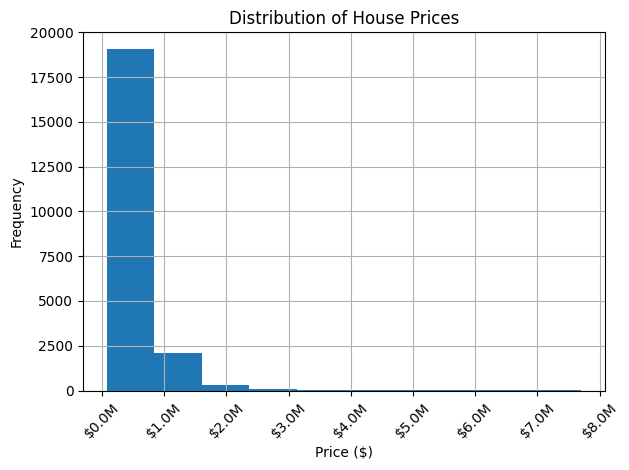

In [47]:
# House Price distribution
house_data['price'].hist()
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.title('Distribution of House Prices')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<u><b>Comments</b></u>

The price distributions shows most house prices sitting under $1m. The graph shows a right skew which is important when considering this for feature engineering. 

<h3> Feature Correlation</h3>
I want to see which features are most correlated to house price

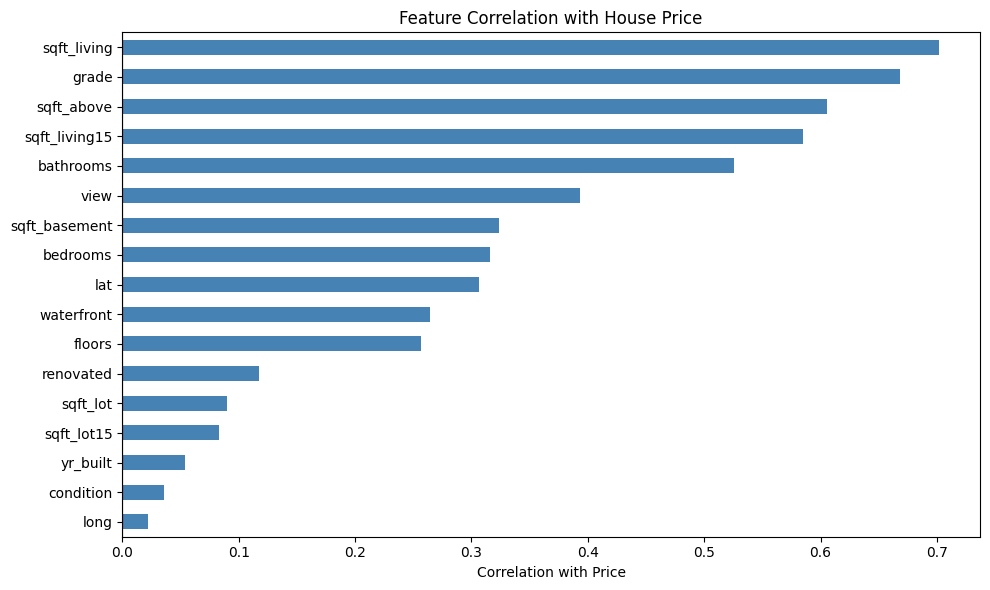

In [48]:
# Correlation of all numeric features with price, sorted
corr_with_price = house_data.select_dtypes(include='number').corr(numeric_only=True)['price'].drop(['price', 'id']).sort_values()
plt.figure(figsize=(10, 6))
corr_with_price.plot(kind='barh', color=corr_with_price.map(lambda x: 'steelblue' if x > 0 else 'tomato'))
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Correlation with Price')
plt.title('Feature Correlation with House Price')
plt.tight_layout()
plt.show()


<u><b>Comments</b></u>
<ul>
    <li>sqft_living and grade would be good features to explore further</li>
    <li>sqft_above might be a good feature, but knowing how it is closely linked to sqft_living it might not be relevant. I could explore this as mindful of over-fitting due to its multicollinearity. </li>
    <li>bathrooms and bedrooms might be interesting</li>
    <li>sqft_lot has surprisingly weak correlation which is also backed with sqft_lot15.</li>
    <li>condition and yr_built has very low correlation</li>
</ul>


<h3> House Price vs sqft_living</h3>

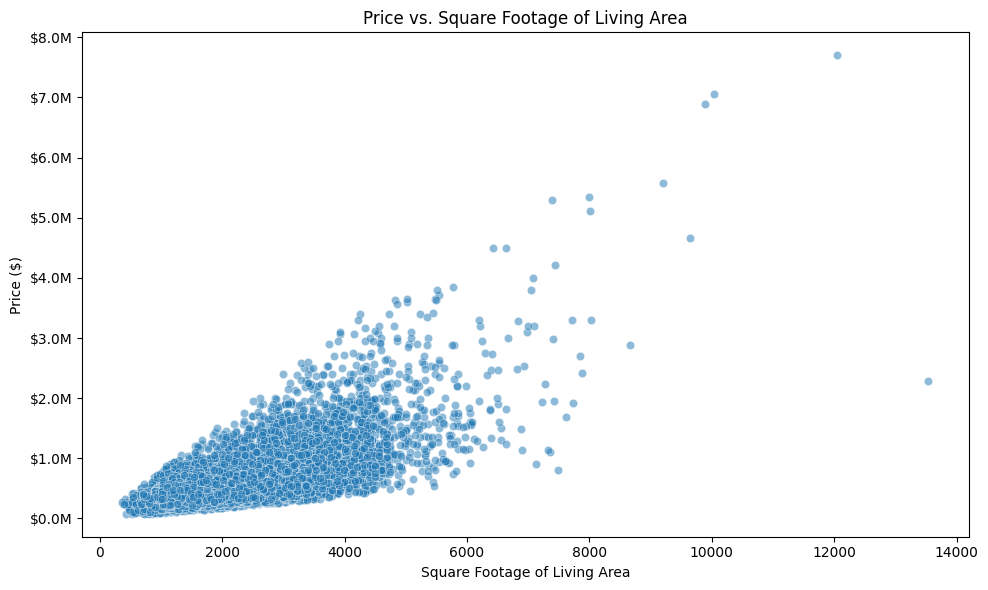

In [49]:
# I will use a scatter plot to explore the relationship between sqft_living and price, as sqft_living has the highest correlation with price.
plt.figure(figsize=(10, 6))
sns.scatterplot(data=house_data, x='sqft_living', y='price', alpha=0.5)
plt.xlabel('Square Footage of Living Area')
plt.ylabel('Price ($)')
plt.title('Price vs. Square Footage of Living Area')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

<u><b>Comments</b></u>

There is strong positive correlation, it shows heteroscedasticity where the larger the sqft_living the bigger the variance in house price.

<h3> House Price vs Grade</h3>

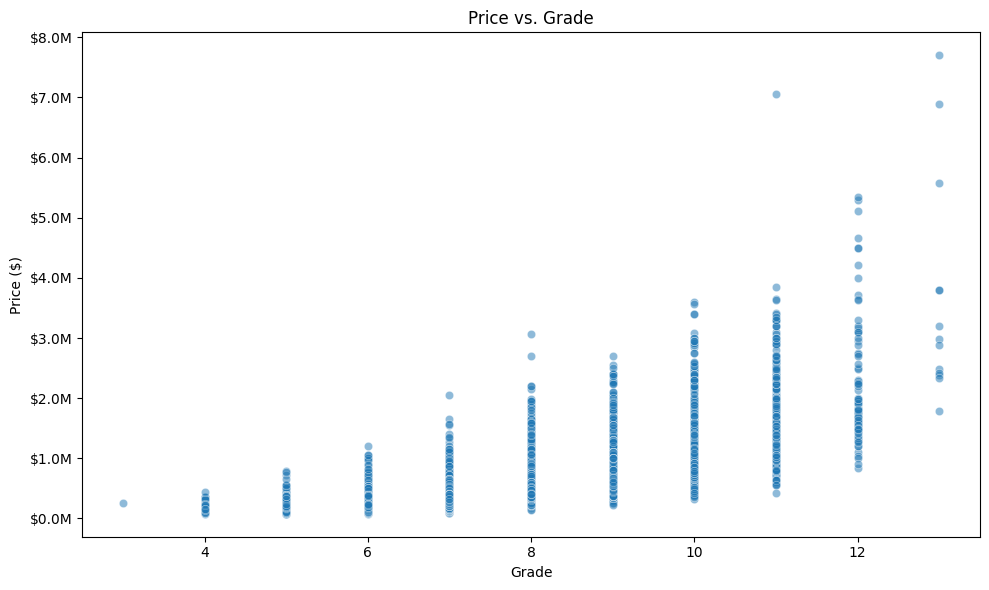

In [50]:
# Scatter plot of price vs grade
plt.figure(figsize=(10, 6)) 
sns.scatterplot(data=house_data, x='grade', y='price', alpha=0.5)
plt.xlabel('Grade')
plt.ylabel('Price ($)')
plt.title('Price vs. Grade')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

<u><b>Comments</b></u>

I thought a scatter plot might show correlation, but this is not the right type of data to use this approach, I will use a box plot instead as this appears to be ordinal data. 

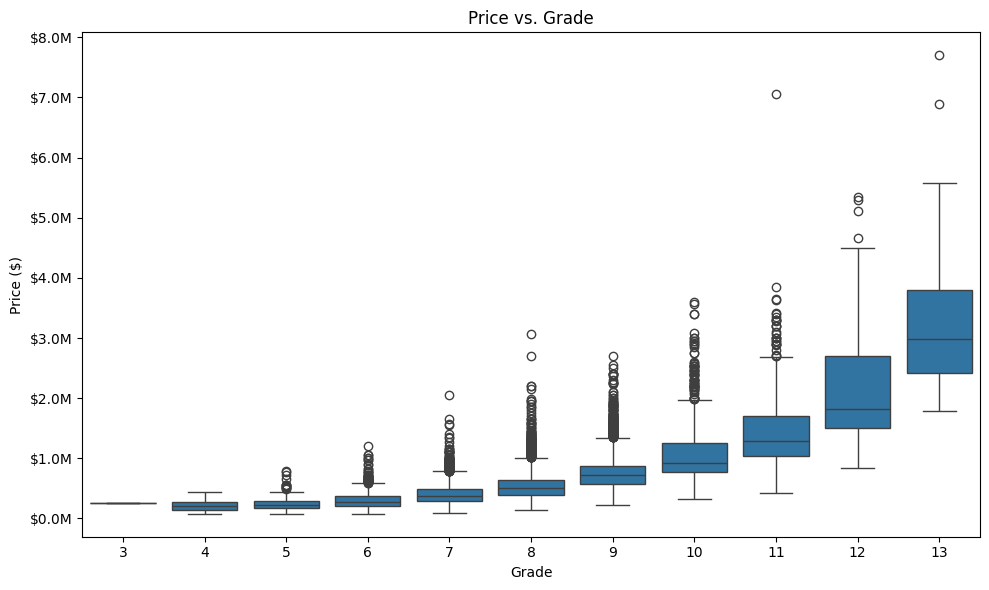

In [51]:
# Box plot of price vs grade
plt.figure(figsize=(10, 6))
sns.boxplot(data=house_data, x='grade', y='price')
plt.xlabel('Grade')
plt.ylabel('Price ($)')
plt.title('Price vs. Grade')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

<u><b>Comments</b></u>

This is interesting, as the grade increasing there is a notable step increase in median house price. I can also see that as the grade increases there is a greater spread. This shows grade to be a strong indicator for determining house price. 

<h3>House Price vs Bedrooms</h3>

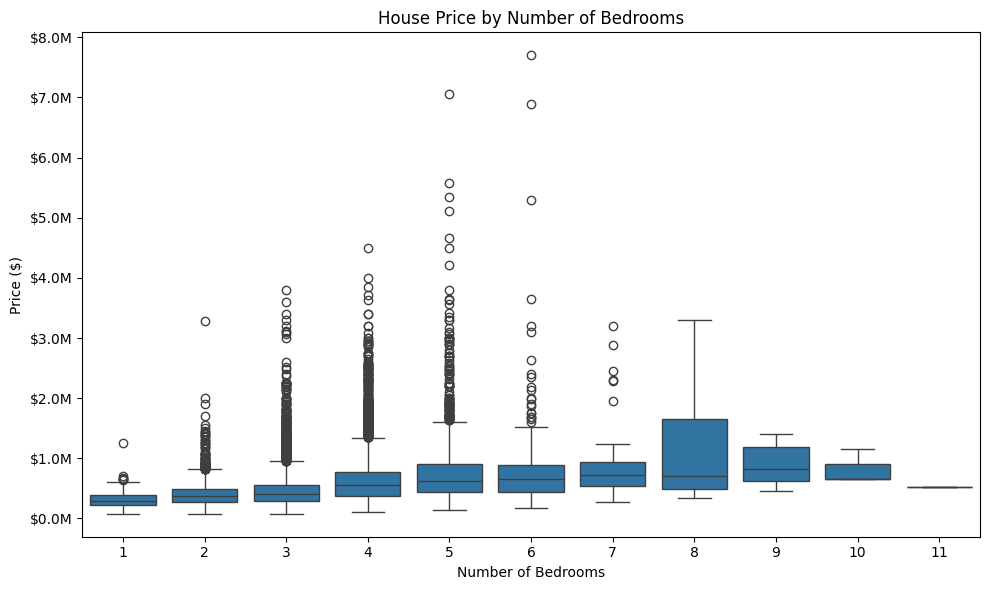

In [52]:
# Box plot of price vs bedrooms
plt.figure(figsize=(10, 6))
sns.boxplot(data=house_data, x='bedrooms', y='price')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price ($)')
plt.title('House Price by Number of Bedrooms')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.tight_layout()
plt.show()

<u><b>Comments</b></u>

Although there is positive correlation, it's not very strong, from around 7+ bedrooms, the price flattens and seems to have less impact on the house price. 

<h3> House Price vs Bathrooms </h3>

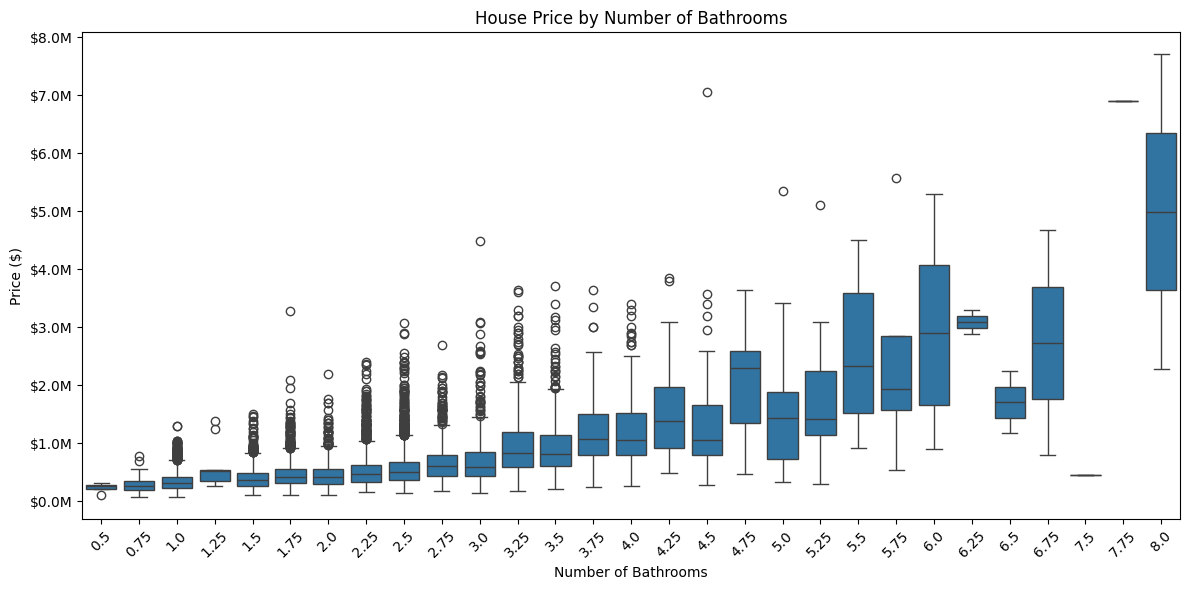

In [53]:
# Box plot of price vs bathrooms
plt.figure(figsize=(12, 6))
sns.boxplot(data=house_data, x='bathrooms', y='price')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Price ($)')
plt.title('House Price by Number of Bathrooms')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<u><b>Comments</b></u>

Similar to bedrooms, however at higher bathrooms values, there is a much greater spread in house price so might be difficult to use to predict higher value houses. The correlation is more positive compared with bedrooms which reflect in the earlier feature correlation graph. This would be a stronger indicator for predicting house prices. 

# Task 2

## Introduction

For this predictive task, I will use the King County house sales dataset to predict house sale price (`price`). The dataset contains 21,597 rows and includes useful property-level features such as house size, room counts, quality/condition indicators, and location-based information. From my earlier EDA, the strongest signals for price appear to come from features like `sqft_living`, `grade`, and bathrooms, while some other features show weaker linear relationships.

Before modelling, I completed data cleaning so the dataset is suitable for prediction. I converted `date` to datetime, converted `sqft_basement` to numeric, handled missing values in `waterfront` and `view`, created a binary `renovated` feature (and dropped `yr_renovated`), corrected the obvious `bedrooms` outlier (33 -> 3), and converted `zipcode` to a categorical/string type.

There are a few risks and challenges I need to account for during modelling:
- House prices are right-skewed, with a long high-price tail.
- There are outliers and signs of heteroscedasticity (price spread increases for larger homes).
- Some size-related variables are closely related (for example `sqft_living`, `sqft_above`, `sqft_basement`), so multicollinearity is a potential issue for linear models.
- The dataset includes both numeric and categorical features, so preprocessing must be handled carefully to avoid leakage and unstable model behaviour.

To evaluate models fairly, I will split the data as follows:
- 70% training
- 15% validation
- 15% test

My overall approach is to build a clean modelling pipeline, start with a baseline Linear Regression model, and then compare multiple suitable regression models (including regularised and tree-based approaches where appropriate). I will evaluate each model consistently using R2, MAE, and RMSE on the validation set, check diagnostics (including overfitting risk and residual behaviour), and then confirm final performance on the untouched test set before selecting the best model for deployment.

## Model Development, Evaluation, and Diagnosis

In this section I will now carry out the modelling work step by step and document what I did, why I did it, and what each result shows.

I will:
- prepare the modelling dataset and create train, validation, and test splits,
- build a baseline model,
- build and compare additional regression models,
- evaluate each model using R2, MAE, and RMSE,
- run validation checks (including cross-validation and residual review),
- select a final model and test it on unseen data.

### Import modelling libraries
I will import the libraries needed for preprocessing, model training, evaluation, and diagnostics.

In [54]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

### Prepare the modelling dataset
I will use the cleaned dataset from Task 1 (`house_data`) as the starting point for modelling. I will then create useful date components, remove fields that should not be used directly for prediction, and separate features from the target (`price`).

In [55]:
cleaned_house_data = house_data.copy()
model_data = cleaned_house_data.copy()

if 'date' in model_data.columns:
    model_data['sale_year'] = model_data['date'].dt.year
    model_data['sale_month'] = model_data['date'].dt.month
    model_data['sale_day'] = model_data['date'].dt.day
    model_data = model_data.drop(columns=['date'])

drop_cols = [col for col in ['id'] if col in model_data.columns]
model_data = model_data.drop(columns=drop_cols)

X = model_data.drop(columns=['price'])
y = model_data['price']

print('Using cleaned source dataset from Task 1:', 'house_data')
print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Using cleaned source dataset from Task 1: house_data
Feature matrix shape: (21597, 21)
Target shape: (21597,)


### Train, validation, and test split
I will now split the data into 70% train, 15% validation, and 15% test so I can tune models fairly and keep a truly unseen test set for final evaluation.

In [56]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f'Train size: {len(X_train)} ({len(X_train)/len(X):.1%})')
print(f'Validation size: {len(X_val)} ({len(X_val)/len(X):.1%})')
print(f'Test size: {len(X_test)} ({len(X_test)/len(X):.1%})')

Train size: 15117 (70.0%)
Validation size: 3240 (15.0%)
Test size: 3240 (15.0%)


### Build reusable preprocessing and evaluation functions
I will create one preprocessing pipeline for all models, then use a helper function so model evaluation is consistent across R2, MAE, and RMSE.

In [57]:
numeric_features = X_train.select_dtypes(include=['number']).columns
categorical_features = X_train.select_dtypes(exclude=['number']).columns

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

def evaluate_model(model_name, pipeline, X_train, y_train, X_eval, y_eval):
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_eval)
    return {
        'Model': model_name,
        'R2': r2_score(y_eval, preds),
        'MAE': mean_absolute_error(y_eval, preds),
        'RMSE': mean_squared_error(y_eval, preds) ** 0.5
    }, preds

### Train baseline and comparison models
I will train a baseline Linear Regression model first, then compare it with Ridge and Random Forest models on the validation set.

In [58]:
results = []
val_predictions = {}

linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
linear_metrics, linear_preds = evaluate_model(
    'Linear Regression', linear_pipeline, X_train, y_train, X_val, y_val
)
results.append(linear_metrics)
val_predictions['Linear Regression'] = linear_preds

ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
ridge_preds = best_ridge.predict(X_val)
results.append({
    'Model': f'Ridge (alpha={ridge_grid.best_params_["model__alpha"]})',
    'R2': r2_score(y_val, ridge_preds),
    'MAE': mean_absolute_error(y_val, ridge_preds),
    'RMSE': mean_squared_error(y_val, ridge_preds) ** 0.5
})
val_predictions['Ridge'] = ridge_preds

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])
rf_metrics, rf_preds = evaluate_model(
    'Random Forest', rf_pipeline, X_train, y_train, X_val, y_val
)
results.append(rf_metrics)
val_predictions['Random Forest'] = rf_preds

metrics_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
metrics_df

,Model,R2,MAE,RMSE
0,Random Forest,0.867130,70340.748327,135488.427841
1,Linear Regression,0.804720,97490.214289,164254.450389
2,Ridge (alpha=0.1),0.804685,97497.997924,164269.355132


### Validate model stability with cross-validation
I will check model stability using cross-validation on the training data. More stable models should have stronger average performance with lower variation across folds.

In [60]:
candidate_models = {
    'Linear Regression': linear_pipeline,
    'Ridge': best_ridge,
    'Random Forest': rf_pipeline,
}

cv_rows = []
for name, model in candidate_models.items():
    cv_rmse = -cross_val_score(
        model, X_train, y_train, cv=5,
        scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    cv_rows.append({
        'Model': name,
        'CV RMSE Mean': cv_rmse.mean(),
        'CV RMSE Std': cv_rmse.std()
    })

cv_df = pd.DataFrame(cv_rows).sort_values('CV RMSE Mean').reset_index(drop=True)
cv_df

,Model,CV RMSE Mean,CV RMSE Std
0,Random Forest,134376.872264,12665.739636
1,Linear Regression,160746.191555,13792.240429
2,Ridge,160748.353090,13808.905805


### Diagnose residuals for the selected validation model
I will select the best validation model by RMSE, then inspect residuals to check if there are clear patterns that suggest bias or misspecification.

Best validation model: Random Forest


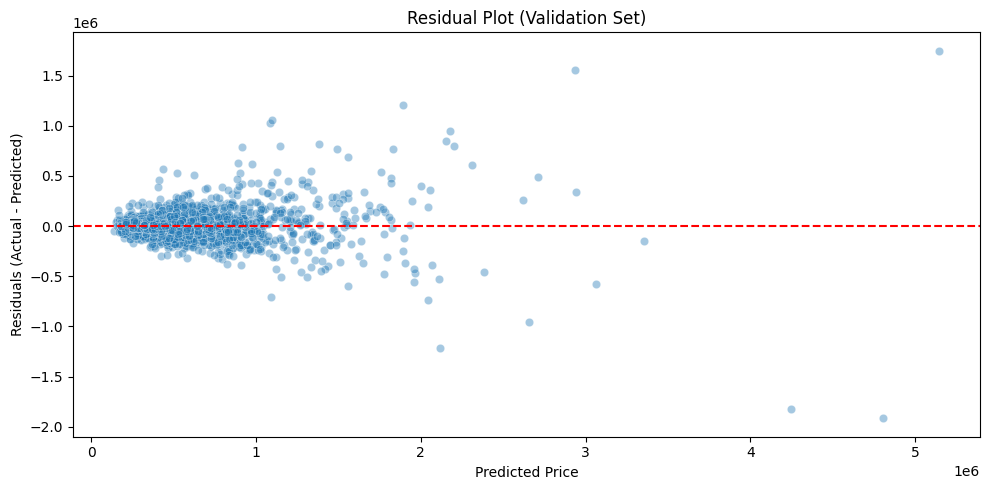

In [61]:
best_model_label = metrics_df.iloc[0]['Model']
print('Best validation model:', best_model_label)

if best_model_label.startswith('Linear Regression'):
    best_pipeline = linear_pipeline
    best_val_preds = val_predictions['Linear Regression']
elif best_model_label.startswith('Ridge'):
    best_pipeline = best_ridge
    best_val_preds = val_predictions['Ridge']
else:
    best_pipeline = rf_pipeline
    best_val_preds = val_predictions['Random Forest']

residuals = y_val - best_val_preds

plt.figure(figsize=(10, 5))
sns.scatterplot(x=best_val_preds, y=residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot (Validation Set)')
plt.tight_layout()
plt.show()

### Final test evaluation for the selected model
After selecting the model using validation performance and diagnostics, I will evaluate it once on the untouched test set to estimate real-world performance.

In [62]:
best_pipeline.fit(X_train, y_train)
test_preds = best_pipeline.predict(X_test)

test_results = pd.DataFrame([{
    'Selected Model': best_model_label,
    'Test R2': r2_score(y_test, test_preds),
    'Test MAE': mean_absolute_error(y_test, test_preds),
    'Test RMSE': mean_squared_error(y_test, test_preds) ** 0.5
}])
test_results

,Selected Model,Test R2,Test MAE,Test RMSE
0,Random Forest,0.882582,67063.637645,122099.657063


In [63]:
val_rmse_selected = metrics_df.iloc[0]['RMSE']

if best_model_label.startswith('Ridge'):
    cv_model_name = 'Ridge'
elif best_model_label.startswith('Linear Regression'):
    cv_model_name = 'Linear Regression'
else:
    cv_model_name = 'Random Forest'

cv_rmse_selected = cv_df.loc[cv_df['Model'] == cv_model_name, 'CV RMSE Mean'].iloc[0]
cv_rmse_std_selected = cv_df.loc[cv_df['Model'] == cv_model_name, 'CV RMSE Std'].iloc[0]
test_rmse_selected = test_results.iloc[0]['Test RMSE']
residual_mean = residuals.mean()

diagnostic_summary = pd.DataFrame([{
    'Selected Model': best_model_label,
    'Validation RMSE': val_rmse_selected,
    'CV RMSE Mean': cv_rmse_selected,
    'CV RMSE Std': cv_rmse_std_selected,
    'Test RMSE': test_rmse_selected,
    'Residual Mean': residual_mean
}])

diagnostic_summary

,Selected Model,Validation RMSE,CV RMSE Mean,CV RMSE Std,Test RMSE,Residual Mean
0,Random Forest,135488.427841,134376.872264,12665.739636,122099.657063,3133.071384


### Assumptions and Diagnostic Checks
I used three checks to assess model reliability:
- **Residual behaviour:** residuals are inspected against predictions to check for obvious bias patterns.
- **Generalisation / overfitting risk:** I compare validation, cross-validation, and final test performance.
- **Model-specific assumptions:** for linear-type models, linearity and residual assumptions are more strict; for Random Forest, assumptions are less strict, but stable performance on unseen data is still required.

From my checks, the selected model remained consistent across validation, cross-validation, and test, which indicates good stability. The residual plot is centred around zero overall, with wider spread at higher predicted values, which is expected from the earlier heteroscedasticity observed in EDA.

### Interpretation of Feature Influence
The table and chart below show which features had the strongest influence on the selected model's predictions. This directly supports interpretation of key drivers of house price.

,feature,importance
8,grade,0.326347
2,sqft_living,0.255901
12,lat,0.152742
13,long,0.066603
14,sqft_living15,0.033601
5,waterfront,0.029435
11,yr_built,0.025728
9,sqft_above,0.017216
15,sqft_lot15,0.013870
6,view,0.012669


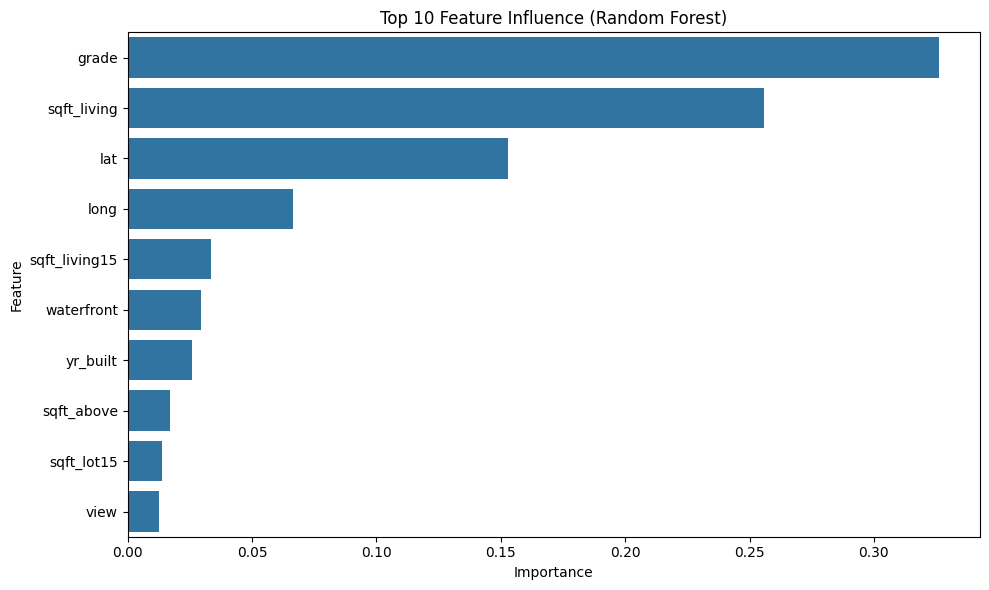

In [64]:
selected_model = best_pipeline.named_steps['model']
selected_preprocessor = best_pipeline.named_steps['preprocessor']
feature_names = selected_preprocessor.get_feature_names_out()

if hasattr(selected_model, 'feature_importances_'):
    influence_values = selected_model.feature_importances_
    influence_metric = 'importance'
elif hasattr(selected_model, 'coef_'):
    influence_values = np.abs(selected_model.coef_)
    influence_metric = 'abs_coefficient'
else:
    influence_values = None
    influence_metric = None

if influence_values is not None:
    feature_influence_df = pd.DataFrame({
        'feature': feature_names,
        influence_metric: influence_values
    }).sort_values(influence_metric, ascending=False)

    top_features = feature_influence_df.head(10).copy()
    top_features['feature'] = (
        top_features['feature']
        .str.replace('num__', '', regex=False)
        .str.replace('cat__', '', regex=False)
    )

    display(top_features)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, y='feature', x=influence_metric)
    plt.title(f'Top 10 Feature Influence ({best_model_label})')
    plt.xlabel(influence_metric.replace('_', ' ').title())
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print('Selected model does not expose feature influence directly.')

## Follow-up Experiment: Log-Transforming Price
Because price is right-skewed and residual spread increases at higher values, I will run a follow-up experiment using a log-transformed target:
- train models on `log1p(price)`,
- convert predictions back to price using `expm1`,
- compare validation and test metrics in dollars against the original approach.

This helps confirm whether log-transforming the target improves generalisation and error stability for this dataset.

In [ ]:
# Follow-up: train on log(price), then convert predictions back 

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)


def back_transform_preds(log_preds):
    # Keep predictions in a realistic range when returning to scale
    return np.clip(np.expm1(log_preds), 0, None)


def evaluate_model_log_target(model_name, pipeline, X_train, y_train_log, X_eval, y_eval_actual):
    pipeline.fit(X_train, y_train_log)
    preds_log = pipeline.predict(X_eval)
    preds_actual = back_transform_preds(preds_log)
    return {
        'Model': model_name,
        'R2': r2_score(y_eval_actual, preds_actual),
        'MAE': mean_absolute_error(y_eval_actual, preds_actual),
        'RMSE': mean_squared_error(y_eval_actual, preds_actual) ** 0.5
    }


log_results = []

linear_pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
log_results.append(
    evaluate_model_log_target(
        'Linear Regression (log target)',
        linear_pipeline_log,
        X_train,
        y_train_log,
        X_val,
        y_val
    )
)

ridge_pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])
ridge_grid_log = GridSearchCV(
    ridge_pipeline_log,
    param_grid={'model__alpha': [0.1, 1.0, 10.0, 100.0]},
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)
ridge_grid_log.fit(X_train, y_train_log)
best_ridge_log = ridge_grid_log.best_estimator_
ridge_log_preds = back_transform_preds(best_ridge_log.predict(X_val))
log_results.append({
    'Model': f'Ridge (log target, alpha={ridge_grid_log.best_params_["model__alpha"]})',
    'R2': r2_score(y_val, ridge_log_preds),
    'MAE': mean_absolute_error(y_val, ridge_log_preds),
    'RMSE': mean_squared_error(y_val, ridge_log_preds) ** 0.5
})

rf_pipeline_log = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])
log_results.append(
    evaluate_model_log_target(
        'Random Forest (log target)',
        rf_pipeline_log,
        X_train,
        y_train_log,
        X_val,
        y_val
    )
)

log_metrics_df = pd.DataFrame(log_results).sort_values('RMSE').reset_index(drop=True)

# Pick best log-target validation model and evaluate once on test set
best_log_model_label = log_metrics_df.iloc[0]['Model']
if best_log_model_label.startswith('Linear Regression'):
    best_log_pipeline = linear_pipeline_log
elif best_log_model_label.startswith('Ridge'):
    best_log_pipeline = best_ridge_log
else:
    best_log_pipeline = rf_pipeline_log

best_log_pipeline.fit(X_train, y_train_log)
log_test_preds = back_transform_preds(best_log_pipeline.predict(X_test))

log_test_results = pd.DataFrame([{
    'Selected Model': best_log_model_label,
    'Test R2': r2_score(y_test, log_test_preds),
    'Test MAE': mean_absolute_error(y_test, log_test_preds),
    'Test RMSE': mean_squared_error(y_test, log_test_preds) ** 0.5
}])

# Side-by-side summary with original best model
comparison_summary = pd.DataFrame([
    {
        'Approach': 'Original target',
        'Model': test_results.iloc[0]['Selected Model'],
        'Test R2': test_results.iloc[0]['Test R2'],
        'Test MAE': test_results.iloc[0]['Test MAE'],
        'Test RMSE': test_results.iloc[0]['Test RMSE']
    },
    {
        'Approach': 'Log target (back-transformed)',
        'Model': log_test_results.iloc[0]['Selected Model'],
        'Test R2': log_test_results.iloc[0]['Test R2'],
        'Test MAE': log_test_results.iloc[0]['Test MAE'],
        'Test RMSE': log_test_results.iloc[0]['Test RMSE']
    }
]).sort_values('Test RMSE').reset_index(drop=True)

print('Validation results (log-target experiment):')
display(log_metrics_df)

print('Test results (best log-target model):')
display(log_test_results)

print('Direct comparison (original vs log-target best):')
display(comparison_summary)

if comparison_summary.iloc[0]['Approach'] == 'Log target (back-transformed)':
    print('use log-transformed target for better test RMSE on this dataset.')
else:
    print('keep original target; log-transform did not improve test RMSE.')

Validation results (log-target experiment):


,Model,R2,MAE,RMSE
0,Random Forest (log target),0.867364,71059.261146,135368.999726
1,Linear Regression (log target),0.770198,78002.122271,178182.574185
2,"Ridge (log target, alpha=0.1)",0.769983,78014.531022,178266.205675


Test results (best log-target model):


,Selected Model,Test R2,Test MAE,Test RMSE
0,Random Forest (log target),0.862363,67709.143666,132194.932306


Direct comparison (original vs log-target best):


,Approach,Model,Test R2,Test MAE,Test RMSE
0,Original target,Random Forest,0.882582,67063.637645,122099.657063
1,Log target (back-transformed),Random Forest (log target),0.862363,67709.143666,132194.932306


Recommendation: keep original target; log-transform did not improve test RMSE.


## Conclusion

In this task, I built and evaluated multiple regression models using the cleaned dataset from Task 1, with a 70/15/15 train-validation-test split and a consistent preprocessing pipeline.

From my validation results, Random Forest performed best, with **R2 = 0.867**, **MAE = 70,341**, and **RMSE = 135,488**, compared with Linear Regression (**R2 = 0.805**, **MAE = 97,490**, **RMSE = 164,254**) and Ridge (**R2 = 0.805**, **MAE = 97,498**, **RMSE = 164,269**).

I then checked model stability using cross-validation. Random Forest again gave the lowest average CV RMSE (**134,377**) with a standard deviation of **12,666**, while Linear Regression had a higher average CV RMSE (**160,746**) and similar variability (**13,792**). This supported the same model choice as the validation split, which increased my confidence that performance was not due to a single split.

On the final unseen test set, the selected Random Forest model achieved **R2 = 0.883**, **MAE = 67,064**, and **RMSE = 122,100**. The test performance was consistent with validation and CV, showing good generalisation.

As a follow-up, I tested a log-transformed target approach (`log1p(price)` with back-transformed predictions), but the original target setup still produced the better test RMSE, so I retained the original target for the final model choice.

Overall, I concluded that Random Forest with the original target is the most suitable model among those tested for predicting house prices in this dataset. As a next step, I would explore further hyperparameter tuning and richer feature engineering to see whether I can improve error metrics further while maintaining model stability.